In [7]:
import numpy as np
import pandas as pdX
import keras
from keras import layers
from matplotlib import pyplot as plt

                         value
timestamp                     
2014-04-01 00:00:00  18.324919
2014-04-01 00:05:00  21.970327


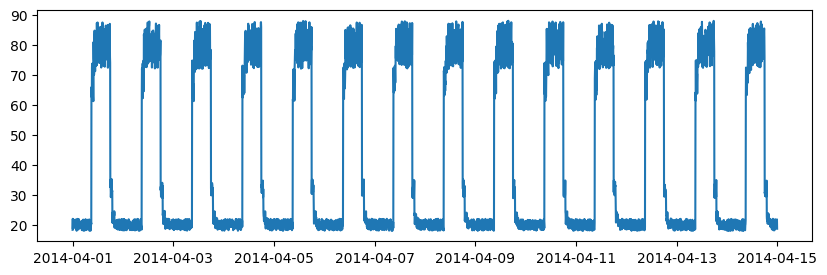

In [32]:
df_small_noise = pd.read_csv('../datasets/time_series_anomaly/art_daily_small_noise.csv', parse_dates=True, index_col="timestamp")
print(df_small_noise.head(2))
plt.figure(figsize=(10,3))
plt.plot(df_small_noise)
plt.show()

In [3]:
df_small_noise

,value
timestamp,
2014-04-01 00:00:00,18.324919
2014-04-01 00:05:00,21.970327
2014-04-01 00:10:00,18.624806
2014-04-01 00:15:00,21.953684
2014-04-01 00:20:00,21.909120
...,...
2014-04-14 23:35:00,20.211195
2014-04-14 23:40:00,20.531041
2014-04-14 23:45:00,19.032127


                         value
timestamp                     
2014-04-01 00:00:00  19.761252
2014-04-01 00:05:00  20.500833


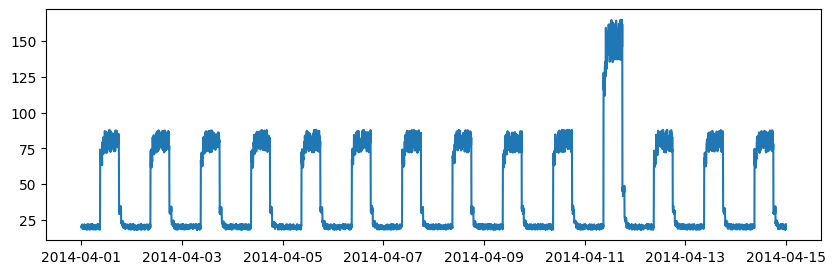

In [11]:
df_daily_jumpsup  = pd.read_csv('../datasets/time_series_anomaly/art_daily_jumpsup.csv', parse_dates=True, index_col="timestamp")
print(df_daily_jumpsup.head(2))
plt.figure(figsize=(10,3))
plt.plot(df_daily_jumpsup)
plt.show()

In [34]:
# Normalize and save the mean and std we get,
# for normalizing test data.
testing_mean = df_daily_jumpsup.mean()
testing_std = df_daily_jumpsup.std()
df_testing_value = (df_daily_jumpsup - testing_mean) / testing_std
print("Number of testing samples:", len(df_testing_value))

Number of testing samples: 4032


In [ ]:
# Normalize and save the mean and std we get,
# for normalizing test data.
training_mean = df_small_noise.mean()
training_std = df_small_noise.std()
df_training_value = (df_small_noise - training_mean) / training_std
print("Number of training samples:", len(df_training_value))

In [35]:
# Get data values from the training timeseries data file and normalize the value data.
# We have a value for every 5 mins for 14 days. 24 * 60 / 5 = 288 timesteps per day

TIME_STEPS = 288


# Generated training sequences for use in the model.
# We slide a window of 288 samples on the data (with overlaps - the window slides by 1). 
# Each slice is a training sequence.

def create_sequences(values, time_steps=TIME_STEPS):
    print(len(values) - time_steps + 1)
    output = []
    for i in range(len(values) - time_steps + 1):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)


x_train = create_sequences(df_training_value.values)
print("Training input shape: ", x_train.shape)

x_test = create_sequences(df_testing_value.values)
print("Testing input shape: ", x_test.shape)

3745
Training input shape:  (3745, 288, 1)
3745
Testing input shape:  (3745, 288, 1)


In [14]:
model = keras.Sequential(
    [
        layers.Input(shape=(x_train.shape[1], x_train.shape[2])),
        layers.Conv1D(
            filters=32,
            kernel_size=7,
            padding="same",
            strides=2,
            activation="relu",
        ),
        layers.Dropout(rate=0.2),
        layers.Conv1D(
            filters=16,
            kernel_size=7,
            padding="same",
            strides=2,
            activation="relu",
        ),
        layers.Conv1DTranspose(
            filters=16,
            kernel_size=7,
            padding="same",
            strides=2,
            activation="relu",
        ),
        layers.Dropout(rate=0.2),
        layers.Conv1DTranspose(
            filters=32,
            kernel_size=7,
            padding="same",
            strides=2,
            activation="relu",
        ),
        layers.Conv1DTranspose(filters=1, kernel_size=7, padding="same"),
    ]
)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 144, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 144, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 72, 16)         │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 144, 16)        │         1,808 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 144, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 288, 32)        │         3,616 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 288, 1)         │           225 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,505 (37.13 KB)

 Trainable params: 9,505 (37.13 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, mode="min")
    ],
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.8217 - val_loss: 0.2226
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1373 - val_loss: 0.0419
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0624 - val_loss: 0.0336
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0505 - val_loss: 0.0310
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0441 - val_loss: 0.0284
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0395 - val_loss: 0.0266
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0365 - val_loss: 0.0248
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0336 - val_loss: 0.0226
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0312 - val_loss: 0.0212
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0294 - val_loss: 0.0207
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0277 - val_loss: 0.0203
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

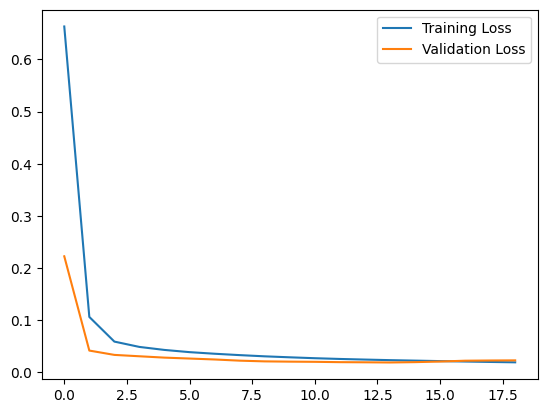

In [19]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()

118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


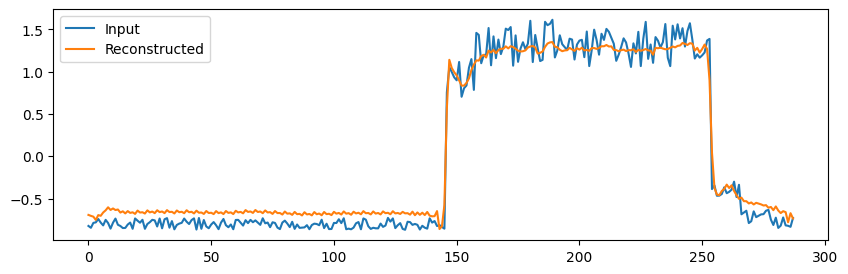

In [31]:
index = 250
plt.figure(figsize=(10,3))
plt.plot(x_train[index], label="Input")
plt.plot(model.predict(x_train)[index], label="Reconstructed")
plt.legend()
plt.show()


118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


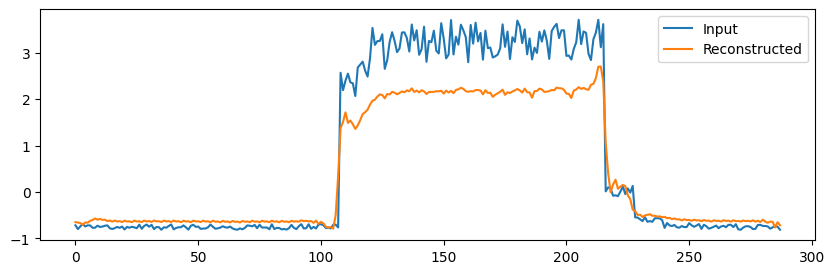

In [49]:
index = 3744-288-288-288
plt.figure(figsize=(10,3))
plt.plot(x_test[index], label="Input")
plt.plot(model.predict(x_test)[index], label="Reconstructed")
plt.legend()
plt.show()

118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
(3745,)


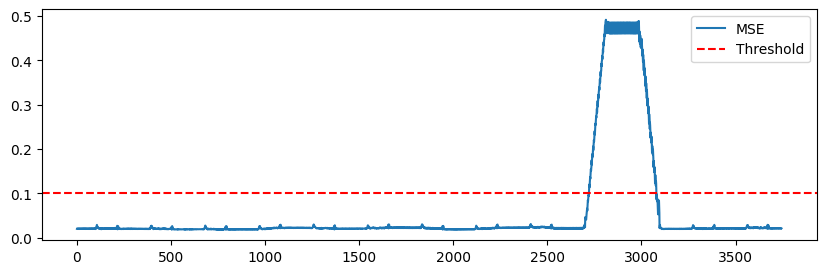

In [54]:
pred = model.predict(x_test)
pred.shape

# compute mse for each sample
mse = np.mean((x_test - pred)**2, axis=(1, 2))
print(mse.shape)

# plot the mse for each sample
plt.figure(figsize=(10,3))
plt.plot(mse, label="MSE")
plt.axhline(y=0.1, color='r', linestyle='--', label="Threshold")    
plt.legend()
plt.show()

In [27]:
x_train.shape

(3745, 288, 1)

In [24]:
x_train.shape

(3745, 288, 1)